# Kapitel 12

In [1]:
from PIL import Image
from IPython.display import display # Für Jupyter 

In [2]:
img = Image.new('L', (300, 200), color=100)
img.show()

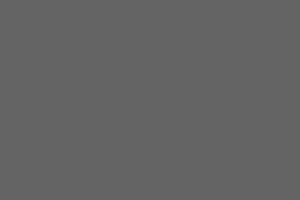

In [3]:
from IPython.display import display
display(img)

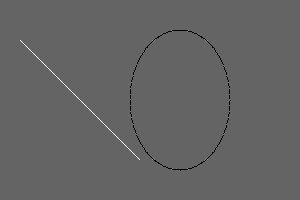

In [4]:
for x in range(20,140):
    img.putpixel((x, x+20),255)
import math
for t in range(360):
    phi=t/180*math.pi
    x=int(180+50*math.cos(phi))
    y=int(100+70*math.sin(phi))
    img.putpixel((int(x),int(y)),0)
display(img)

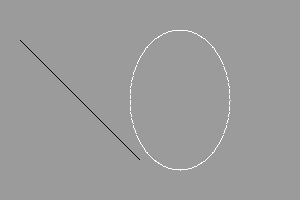

In [5]:
for x in range(img.size[0]):
    for y in range(img.size[1]):
        img.putpixel((x,y),255-img.getpixel((x,y)))
display(img)

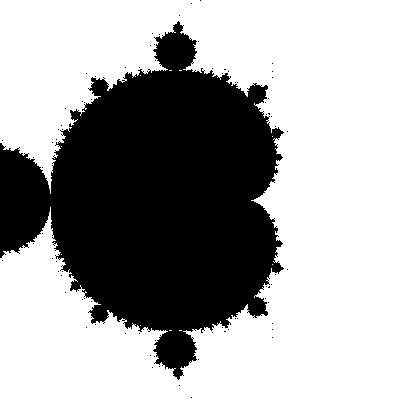

In [6]:
n=400;
img2= Image.new('L', (n,n), color=0)
for ix in range(n):
    for iy in range(n):
        x=(ix-n/2)/(n/2) # Also Realteil -1…1
        y=(iy-n/2)/(n/2) # Ebenso Imaginärteil -1…1
        c=complex(x,y)
        z=0
        for i in range(100):
            z=z**2+c
            if abs(z)>2: # Folge divergiert
                img2.putpixel((ix,iy),255)
                break
display(img2)

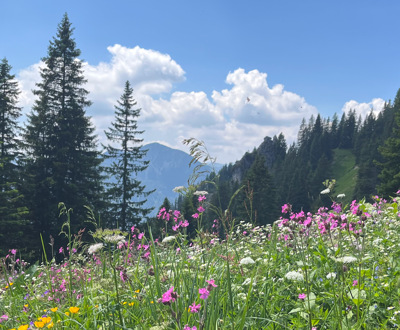

(400, 330)

In [7]:
bild=Image.open("foto.jpg")
display(bild)
bild.size

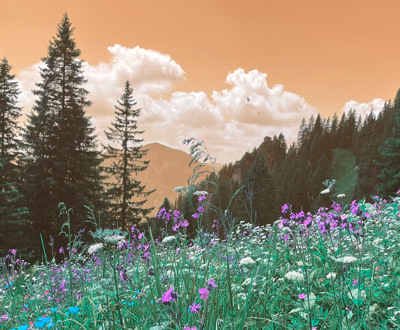

In [8]:
bild2=Image.open("foto.jpg")
for x in range(bild2.size[0]):
    for y in range(bild2.size[1]):
        (r,g,b)=bild2.getpixel((x,y))
        bild2.putpixel((x,y),(b,g,r))
display(bild2)

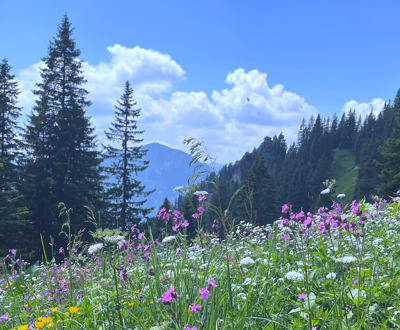

In [9]:
bild2=Image.open("foto.jpg")
for x in range(bild2.size[0]):
    for y in range(bild2.size[1]):
        (r,g,b)=bild2.getpixel((x,y))
        bild2.putpixel((x,y),(int(r*0.9),g,int(1.2*b)))
display(bild2)

In [10]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output

positionen=[]
def rotheit(farbe:tuple)->float:
    (r,g,b)=farbe
    return r-g/2-b/2
def PIL_bearbeitung(frame):
    # Konvertierung OpenCV BGR → RGB → PIL
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(img_rgb)
    # Bearbeitung mit PIL:
    maxred=0; maxpos=(0,0) # Bisher gefundenes Maximum
    for x in range(0,img.size[0],5):
        for y in range(0,img.size[1],5):
            farbe=img.getpixel((x,y))
            if rotheit(farbe)>maxred:
                maxred=rotheit(farbe); maxpos=(x,y)
    positionen.append(maxpos)
    for x in range(maxpos[0],min(maxpos[0]+30,img.size[0])):
        for y in range(maxpos[1],min(maxpos[1]+30,img.size[1])):
            img.putpixel((x,y),(0,255,0))
    # PIL zurück zu NumPy
    return np.array(img)

# Webcam öffnen
try:
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        img_np = PIL_bearbeitung(frame)
        clear_output(wait=True)
        plt.imshow(img_np)
        plt.axis('off'); plt.show()
except KeyboardInterrupt:
    print("Beendet")
cap.release()

Beendet


Traceback (most recent call last):
  File "<string>", line 1, in <module>
    import os, sys, time; time.sleep(20); os.remove(sys.argv[1])
                          ~~~~~~~~~~^^^^
KeyboardInterrupt
